In [14]:
import pypsa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import os
import pypsatopo
import warnings
warnings.filterwarnings("ignore")
import cartopy.crs as ccrs
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)   

### Default Technology Cost DataBase:

In [16]:
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

In [18]:
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

- all capital cost inputs are annualized

In [19]:
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"];

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1);

costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

### Data Inputs

In [20]:
# Get the directory of the current script
current_dir = os.getcwd()

# Build file paths relative to the script location
pv_file = os.path.join(current_dir, "pv_optimal.csv")
wind_file = os.path.join(current_dir, "onshore_wind_1979-2017.csv")
dk1_file = os.path.join(current_dir, "2017_DK1_SpotSprice_Load.xlsx")
# dk1_file = os.path.join(current_dir, "DK1_2017.csv")  # optional alternative

# Read the files
solar_pv_data = pd.read_csv(pv_file, sep=";")
onshore_wind_data = pd.read_csv(wind_file, sep=";")
DK1_data_2017 = pd.read_excel(dk1_file)

In [21]:
solar_pv_data['utc_time'] = pd.to_datetime(solar_pv_data['utc_time']).dt.tz_localize(None)
solar_pv_data.index = pd.DatetimeIndex(solar_pv_data['utc_time'])

onshore_wind_data['utc_time'] = pd.to_datetime(onshore_wind_data['utc_time']).dt.tz_localize(None)
onshore_wind_data.index = pd.DatetimeIndex(onshore_wind_data['utc_time'])

DK1_data_2017["HourUTC"] = pd.to_datetime(DK1_data_2017["HourUTC"], format="%d-%m-%Y %H:%M").dt.tz_localize(None)
DK1_data_2017.index = pd.DatetimeIndex(DK1_data_2017["HourUTC"])

In [64]:
import pandas as pd

# 1. Load the dataset
PV_data = pd.read_csv(
    "Re_Ninja_PV_data_DK.csv", 
    skiprows=3, 
    sep=None, 
    engine='python',
    compression='infer'
)

# 2. Convert 'time' to datetime and remove timezone offset (+00:00)
# This makes it compatible with standard DK1/DK2 weather data
PV_data['time'] = pd.to_datetime(PV_data['time']).dt.tz_localize(None)

# 3. Set the index as a DatetimeIndex and drop the helper column
PV_data.index = pd.DatetimeIndex(PV_data['time'])
PV_data.drop(columns=['time'], inplace=True)

# 4. Clean column names (removes "Unnamed" or accidental whitespace)
PV_data.columns = PV_data.columns.str.strip()

# Display the first few rows to verify
print(PV_data.head())

                     DK01  DK02  DK03  DK04  DK05
time                                             
1980-01-01 00:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 01:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 02:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 03:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 04:00:00   0.0   0.0   0.0   0.0   0.0


<Axes: xlabel='utc_time'>

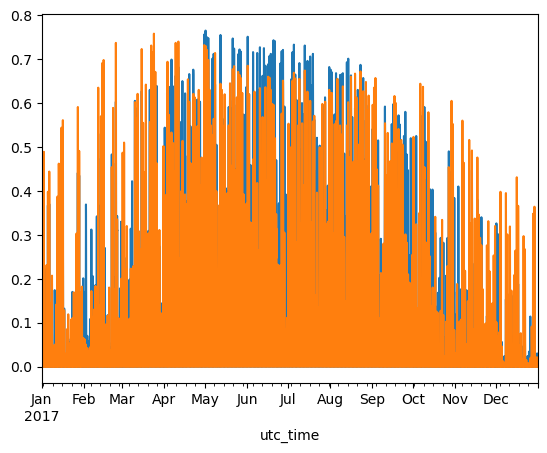

In [ ]:
# C
PV_data["DK01"]["2017-01-01":"2017-12-31"].plot()
solar_pv_data["DNK"]["2017-01-01":"2017-12-31"].plot()